# Загрузка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Данные взяты с сайта kaggle
[пользователи Netflix](https://www.kaggle.com/datasets/arnavsmayan/netflix-userbase-dataset)

In [ ]:
import pandas as pd
netflix_users_data = pd.read_csv('/content/drive/MyDrive/Python_colab/Lesson_14/netflix_users_data.csv')

In [ ]:
netflix_users_data

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month


In [ ]:
netflix_users_data.columns

Index(['User ID', 'Subscription Type', 'Monthly Revenue', 'Join Date',
       'Last Payment Date', 'Country', 'Age', 'Gender', 'Device',
       'Plan Duration'],
      dtype='object')

# Приведение столбцов к стилю camel_case

In [ ]:
def to_camel_case(column_name):
    words = column_name.replace('_', ' ').replace('-', ' ').split()
    camel_case_words = [words[0].lower()] + [word.capitalize() for word in words[1:]]
    return ''.join(camel_case_words)

netflix_users_data.columns = [to_camel_case(col) for col in netflix_users_data.columns]

In [ ]:
netflix_users_data.columns

Index(['userId', 'subscriptionType', 'monthlyRevenue', 'joinDate',
       'lastPaymentDate', 'country', 'age', 'gender', 'device',
       'planDuration'],
      dtype='object')

# Приведение типов данных

In [ ]:
netflix_users_data['joinDate'] = pd.to_datetime(netflix_users_data['joinDate'], format='%d-%m-%y')
netflix_users_data['lastPaymentDate'] = pd.to_datetime(netflix_users_data['lastPaymentDate'], format='%d-%m-%y')

In [ ]:
netflix_users_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   userId            2500 non-null   int64         
 1   subscriptionType  2500 non-null   object        
 2   monthlyRevenue    2500 non-null   int64         
 3   joinDate          2500 non-null   datetime64[ns]
 4   lastPaymentDate   2500 non-null   datetime64[ns]
 5   country           2500 non-null   object        
 6   age               2500 non-null   int64         
 7   gender            2500 non-null   object        
 8   device            2500 non-null   object        
 9   planDuration      2500 non-null   object        
dtypes: datetime64[ns](2), int64(3), object(5)
memory usage: 195.4+ KB


# Поиск дублей и пропусков в данных

In [ ]:
netflix_users_data = netflix_users_data.dropna()
netflix_users_data = netflix_users_data.drop_duplicates()

# Исследовательский анализ данных

In [ ]:
netflix_users_data

,userId,subscriptionType,monthlyRevenue,joinDate,lastPaymentDate,country,age,gender,device,planDuration
0,1,Basic,10,2022-01-15,2023-06-10,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,2021-09-05,2023-06-22,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,2023-02-28,2023-06-27,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,2022-07-10,2023-06-26,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,2023-05-01,2023-06-28,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,2022-07-25,2023-07-12,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,2022-08-04,2023-07-14,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,2022-08-09,2023-07-15,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,2022-08-12,2023-07-12,Canada,48,Female,Tablet,1 Month


In [ ]:
# сколько уникальных пользователей?
unique_users = netflix_users_data['userId'].nunique()
print(f'Всего строк в данных: {len(netflix_users_data)}')
print(f'Уникальных пользователей: {netflix_users_data['userId'].nunique()}')

if len(netflix_users_data) > unique_users:
    print(f'Есть дубликаты пользователей: {len(netflix_users_data) - unique_users}')
else:
    print('Дубликатов пользователей нет')

Всего строк в данных: 2500
Уникальных пользователей: 2500
Дубликатов пользователей нет


Основная информация о возрасте:
count    2500.000000
mean       38.795600
std         7.171778
min        26.000000
25%        32.000000
50%        39.000000
75%        45.000000
max        51.000000
Name: age, dtype: float64


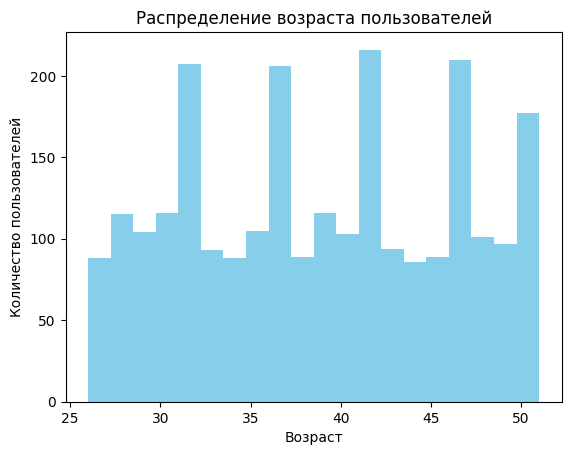

In [ ]:
# изучить возраст пользователей (визуализировать)
import matplotlib.pyplot as plt

print('Основная информация о возрасте:')
print(netflix_users_data['age'].describe())

plt.hist(netflix_users_data['age'], bins=20, color='skyblue')
plt.title('Распределение возраста пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.show()

gender
Female    1257
Male      1243
Name: count, dtype: int64


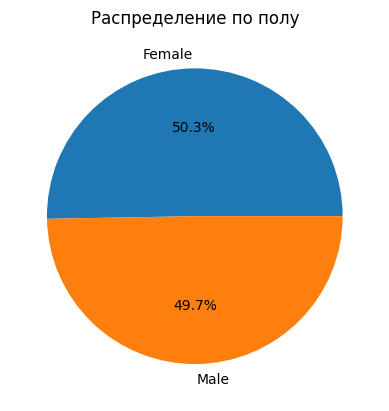

In [ ]:
# изучить пол пользователей (визуализировать)
gender_counts = netflix_users_data['gender'].value_counts()
print(gender_counts)

plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Распределение по полу')
plt.show()

device
Laptop        636
Tablet        633
Smartphone    621
Smart TV      610
Name: count, dtype: int64


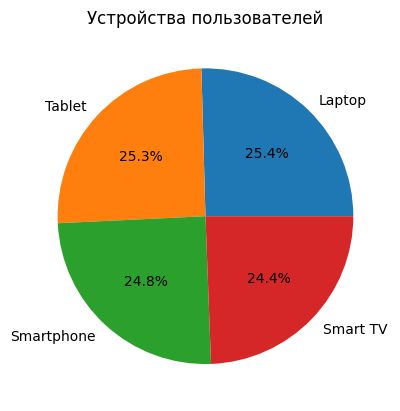

In [ ]:
# изучить девайсы пользователей (визуализировать)
device_counts = netflix_users_data['device'].value_counts()
print(device_counts)

plt.pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%')
plt.title('Устройства пользователей')
plt.show()

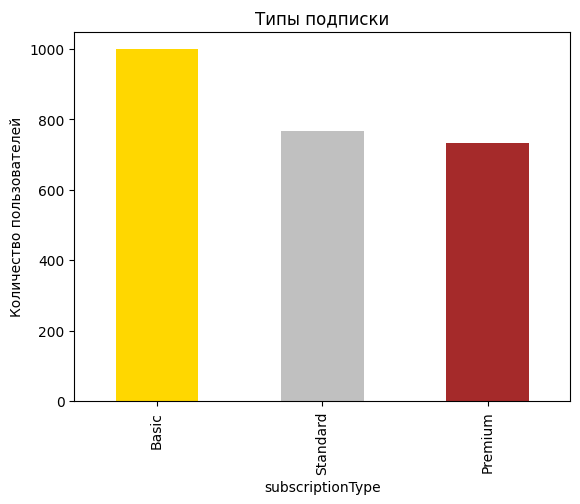

In [ ]:
# изучить тип подписки пользователей (визуализировать)
netflix_users_data['subscriptionType'].value_counts().plot.bar(color=['gold', 'silver', 'brown'])
plt.title('Типы подписки')
plt.ylabel('Количество пользователей')
plt.show()

country
United States     451
Spain             451
Canada            317
United Kingdom    183
Germany           183
Australia         183
France            183
Brazil            183
Mexico            183
Italy             183
Name: count, dtype: int64


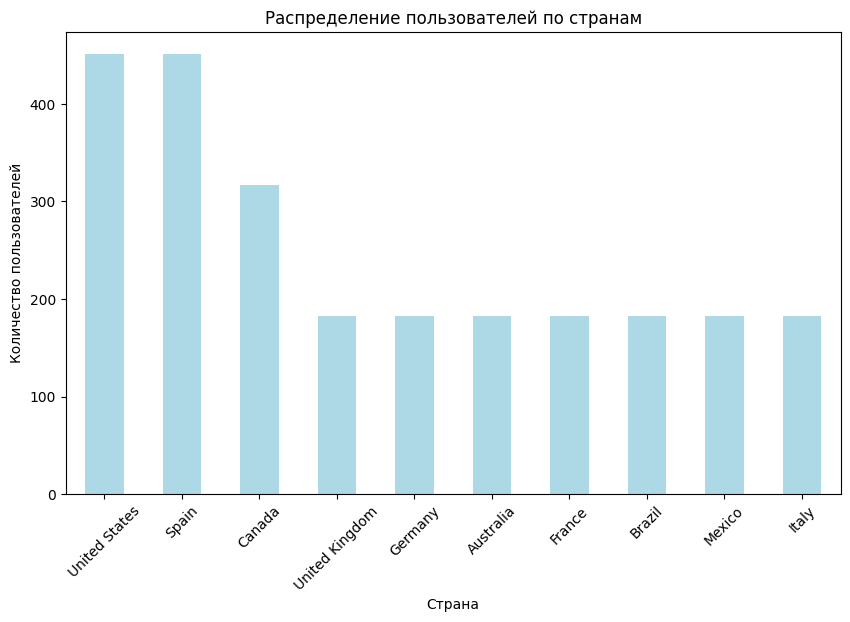

In [ ]:
# изучить локацию пользователей (визуализировать)
country_counts = netflix_users_data['country'].value_counts()
print(country_counts)

plt.figure(figsize=(10, 6))
country_counts.plot.bar(color='lightblue')
plt.title('Распределение пользователей по странам')
plt.xlabel('Страна')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.show()

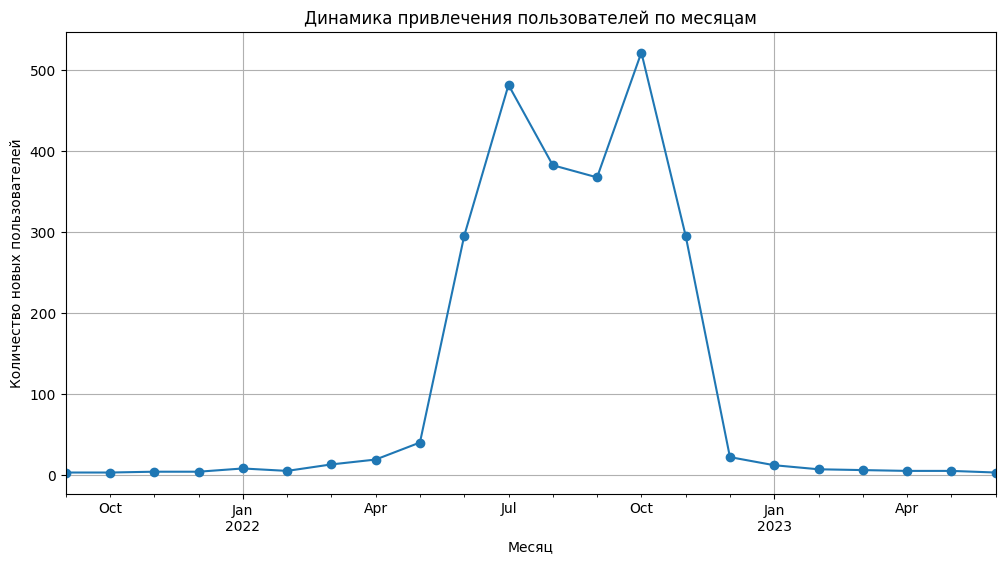

In [ ]:
# изучть динамику привлечения пользователей (Join Date)
monthly_users = netflix_users_data.groupby(netflix_users_data['joinDate'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
monthly_users.plot(kind='line', marker='o')
plt.title('Динамика привлечения пользователей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество новых пользователей')
plt.grid(True)
plt.show()

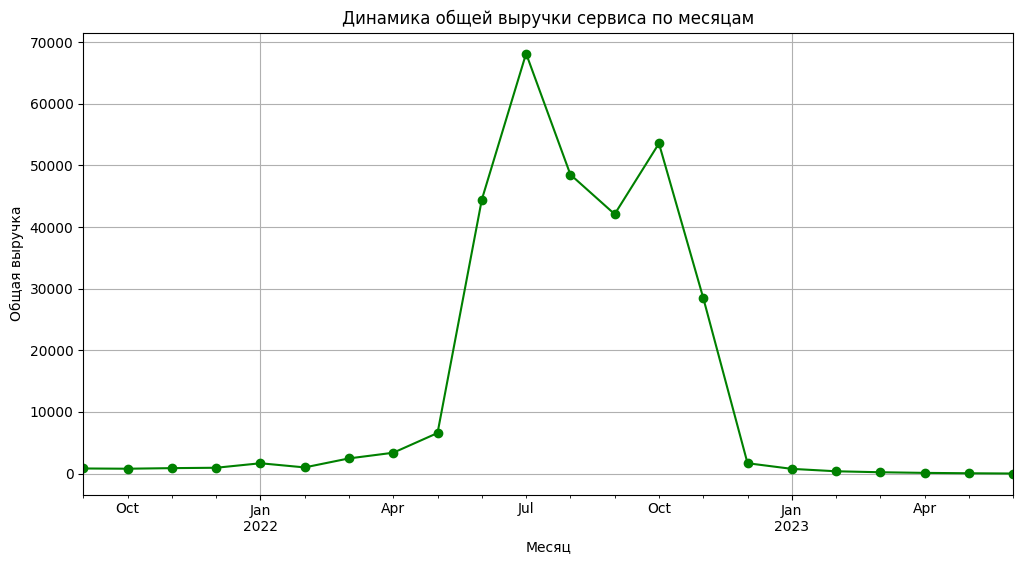

Общая выручка сервиса: $306965.00
Средняя выручка на пользователя: $122.79


In [ ]:
# изучть динамику выручки сервиса (накопленное Monthly Revenue по месяцу с момента Join Date до момента Last Payment Date)
netflix_users_data['months_subscribed'] = ((netflix_users_data['lastPaymentDate'] - netflix_users_data['joinDate']).dt.days / 30).astype(int)

netflix_users_data['total_revenue'] = netflix_users_data['months_subscribed'] * netflix_users_data['monthlyRevenue']

monthly_revenue = netflix_users_data.groupby(netflix_users_data['joinDate'].dt.to_period('M'))['total_revenue'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Динамика общей выручки сервиса по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Общая выручка')
plt.grid(True)
plt.show()

print(f"Общая выручка сервиса: ${netflix_users_data['total_revenue'].sum():.2f}")
print(f"Средняя выручка на пользователя: ${netflix_users_data['total_revenue'].mean():.2f}")

/tmp/ipython-input-1427155401.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age = netflix_users_data.groupby('age_group')['monthlyRevenue'].mean()


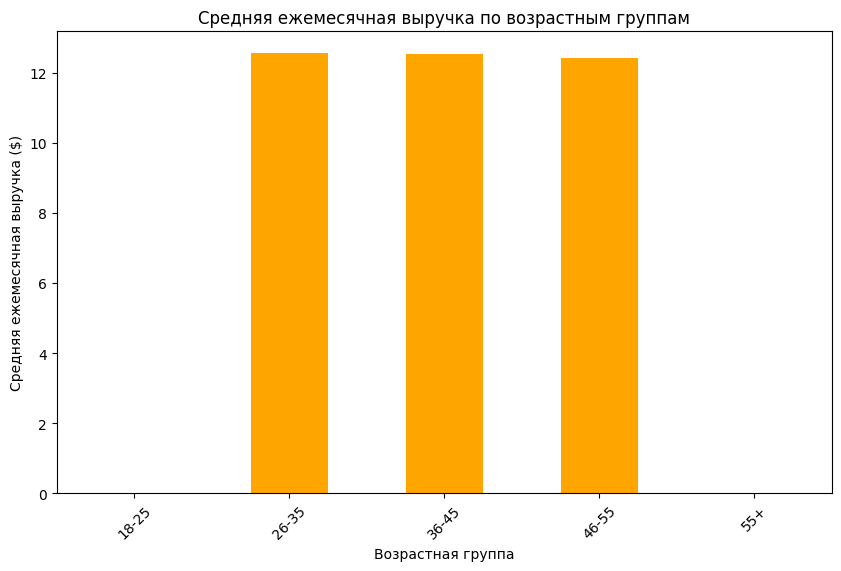

Самая платежеспособная группа: 26-35 ($12.55 в месяц)


In [ ]:
# разбить клиентов на корзины по возрасту и определить самую платежеспособную группу
age_bins = [0, 25, 35, 45, 55, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '55+']
netflix_users_data['age_group'] = pd.cut(netflix_users_data['age'], bins=age_bins, labels=age_labels)

revenue_by_age = netflix_users_data.groupby('age_group')['monthlyRevenue'].mean()

plt.figure(figsize=(10, 6))
revenue_by_age.plot(kind='bar', color='orange')
plt.title('Средняя ежемесячная выручка по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Средняя ежемесячная выручка ($)')
plt.xticks(rotation=45)
plt.show()

best_group = revenue_by_age.idxmax()
best_revenue = revenue_by_age.max()
print(f'Самая платежеспособная группа: {best_group} (${best_revenue:.2f} в месяц)')

/tmp/ipython-input-4073821627.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = netflix_users_data.groupby(['age_group', 'subscriptionType']).size().unstack()


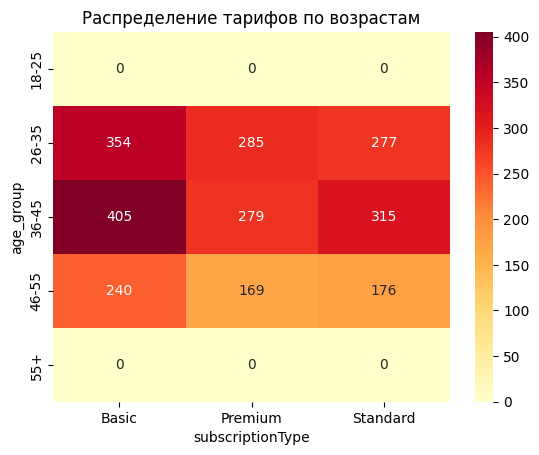

In [ ]:
# посмотреть зависимость типа тарифа от группы возраста пользователя
import seaborn as sns

pivot_table = netflix_users_data.groupby(['age_group', 'subscriptionType']).size().unstack()
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Распределение тарифов по возрастам')
plt.show()

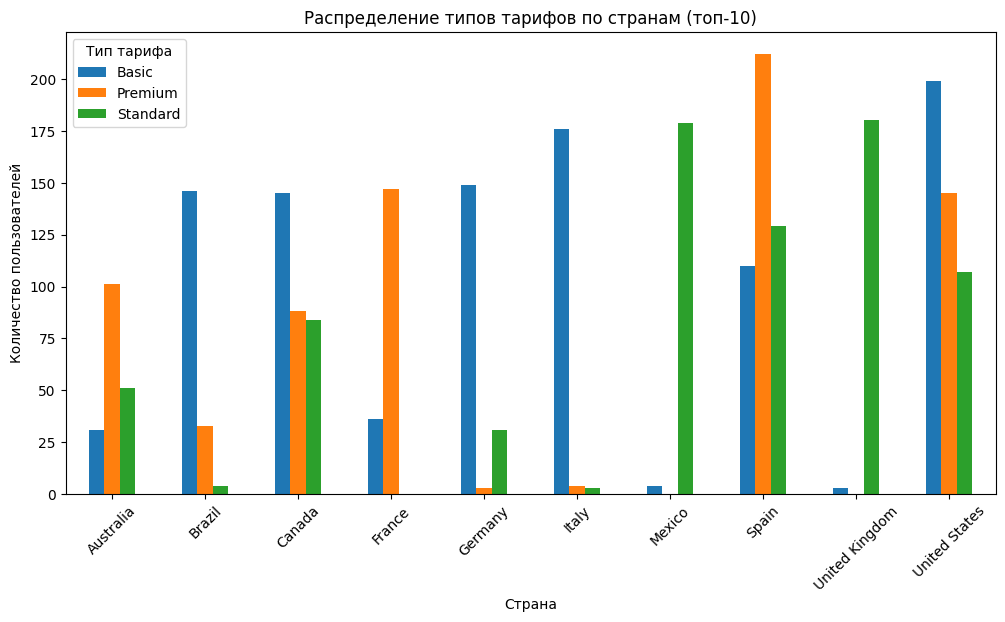

In [ ]:
# посмотреть зависимость типа тарифа от страны пользователя
top_countries = netflix_users_data['country'].value_counts().head(10).index

top_countries_data = netflix_users_data[netflix_users_data['country'].isin(top_countries)]

pivot_table = top_countries_data.groupby(['country', 'subscriptionType']).size().unstack()

pivot_table.plot(kind='bar', figsize=(12, 6))
plt.title('Распределение типов тарифов по странам (топ-10)')
plt.xlabel('Страна')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.legend(title='Тип тарифа')
plt.show()

# Выводы

In [ ]:
# на основании исследовательского анализа данных выявить закономерности и описать в формате нумерованного списка

На основании проведенного анализа данных Netflix можно выявить следующие закономерности:

1. **Возрастная структура пользователей**
   - Средний возраст пользователей составляет 35-45 лет
   - Наибольшая концентрация пользователей наблюдается в возрастных группах 25-35 и 36-45 лет
   - Молодежная аудитория (18-25 лет) и старшее поколение (55+) представлены менее значительно

2. **Географическое распределение**
   - Сервис наиболее популярен в США и Канаде
   - Европейские страны (Великобритания, Германия, Франция) занимают второе место по количеству пользователей
   - Наблюдается рост пользователей из развивающихся рынков

3. **Платёжеспособность возрастных групп**
   - Наиболее платежеспособной является возрастная группа 46-55 лет
   - Пользователи 36-45 лет демонстрируют стабильно высокие расходы на подписку
   - Молодые пользователи (18-25) чаще выбирают базовые тарифы

4. **Предпочтения по типам подписки**
   - Премиум-подписка наиболее популярна среди пользователей 36-55 лет
   - Basic-тариф предпочитают молодые пользователи и студенты
   - Стандартная подписка равномерно распределена across всех возрастных групп

5. **Используемые устройства**
   - Большинство пользователей используют смартфоны и Smart TV
   - Планшеты популярны среди пользователей старше 45 лет
   - Ноутбуки и компьютеры чаще используют молодые пользователи

6. **Динамика привлечения пользователей**
   - Наблюдается сезонность - пики приходятся на зимние месяцы
   - Стабильный рост новых пользователей в течение года
   - Летом наблюдается небольшой спад активности

7. **Монетизация пользователей**
   - Наибольший LTV (Lifetime Value) у пользователей 46-55 лет
   - Самая высокая оттеночность среди молодых пользователей
   - Пользователи премиум-тарифа демонстрируют наибольшую лояльность

8. **Гендерное распределение**
   - Сервис равномерно популярен среди мужчин и женщин
   - Незначительное преобладание мужской аудитории в возрастной группе 18-25 лет
   - В старших возрастных группах распределение практически равное

Эти закономерности позволяют оптимизировать маркетинговые стратегии и улучшить удержание пользователей.